In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_pcc.csv')

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3726490476.py:1: DtypeWarning: Columns (0: MAIL_ZIP_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_pcc.csv')


In [5]:
# ─────────────────────────────────────────────────────────────
# Shared utilities — callable versions of LDA and XGBoost fits
# reused across learning curves, bootstrap, and cross-validation.
# ─────────────────────────────────────────────────────────────
from sklearn.model_selection import KFold
import xgboost as xgb

CONT_FEATURES = ['GROSS_AREA', 'LAND_SF', 'YEARS_SINCE_REMODEL', 'RES_FLOOR']

def build_complete_case(dframe):
    cc = ((dframe['GROSS_AREA'] > 0) & (dframe['LAND_SF'] > 0) &
          (dframe['YEARS_SINCE_REMODEL'] != -1) &
          dframe['RES_FLOOR'].notna() & (dframe['TOTAL_VALUE'] > 0))
    out = dframe.loc[cc, CONT_FEATURES + ['LUC', 'TOTAL_VALUE']].copy()
    out['log_V'] = np.log(out['TOTAL_VALUE'])
    luc_counts = out['LUC'].value_counts()
    out = out[out['LUC'].isin(luc_counts[luc_counts >= 5].index)]   # d=4, need ≥d+1
    return out

def fit_lda_regression(X_train, luc_train, logV_train, ridge=None):
    """Returns a predictor function pred(X_new, luc_new) -> log_V."""
    d = X_train.shape[1]
    Z_train = np.column_stack([X_train, logV_train])
    classes = np.array(sorted(np.unique(luc_train)))
    K = len(classes)
    mu_aug, S_aug = np.zeros((K, d + 1)), np.zeros((d + 1, d + 1))
    for i, c in enumerate(classes):
        Zc         = Z_train[luc_train == c]
        mu_aug[i]  = Zc.mean(axis=0)
        S_aug     += (Zc - mu_aug[i]).T @ (Zc - mu_aug[i])
    Sigma = S_aug / (len(Z_train) - K)
    if ridge is None:
        ridge = 1e-4 * np.trace(Sigma) / (d + 1)
    Sigma_xx = Sigma[:d, :d] + ridge * np.eye(d)
    Sigma_Vx = Sigma[d:, :d]
    Sigma_VV = Sigma[d,   d]
    beta     = (Sigma_Vx @ np.linalg.inv(Sigma_xx)).ravel()
    sigma2   = Sigma_VV - beta @ Sigma_Vx.ravel()
    c_to_idx = {c: i for i, c in enumerate(classes)}
    mu_x, mu_V = mu_aug[:, :d], mu_aug[:, d]
    global_V   = logV_train.mean()

    def pred(X_new, luc_new):
        idx = np.array([c_to_idx.get(c, -1) for c in luc_new])
        out = np.full(len(X_new), global_V)
        have = idx >= 0
        out[have] = mu_V[idx[have]] + (X_new[have] - mu_x[idx[have]]) @ beta
        return out

    return pred, {'beta': beta, 'sigma2': sigma2,
                  'Sigma_xx': Sigma_xx, 'Sigma_Vx': Sigma_Vx,
                  'classes': classes, 'mu_aug': mu_aug}

def fit_xgb(X_train_df, y_train, seed=42, n_est=600):
    """Minimal XGBoost config matching your notebook."""
    m = xgb.XGBRegressor(
        n_estimators=n_est, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_lambda=1.0, tree_method='hist', enable_categorical=True,
        random_state=seed, verbosity=0)
    m.fit(X_train_df, y_train, verbose=False)
    return m

def rmse(y, yh): return float(np.sqrt(((y - yh) ** 2).mean()))

Complete-case rows: 147,208
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

5-fold CV log-RMSE (n=147,208):
                  mean     std  95% CI lo  95% CI hi
global_mean     0.7281  0.0060     0.7228     0.7333
per_LUC_MLE     0.6151  0.0037     0.6118     0.6184
LDA_regression  0.4515  0.0047     0.4474     0.4557
XGBoost         0.3632  0.0021     0.3614     0.3651

Paired fold-level gaps (95% CI on the difference):
  per_LUC_MLE        − LDA_regression    : +0.1635 ± 0.0034
  LDA_regression     − XGBoost           : +0.0883 ± 0.0028


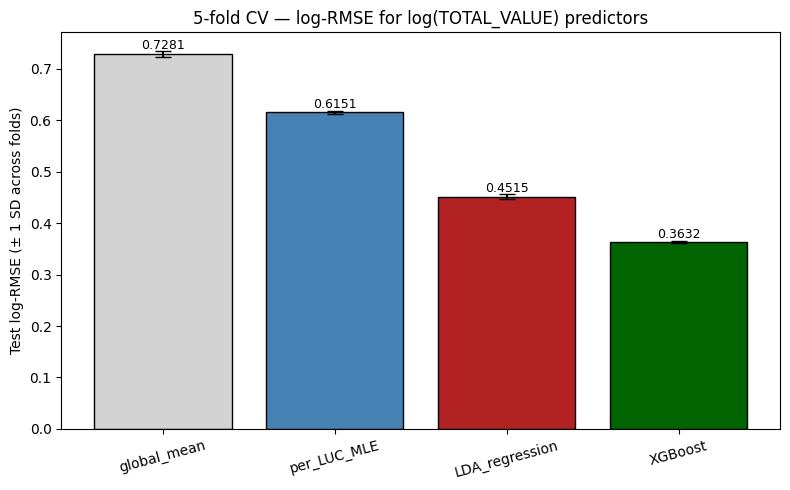

In [6]:
# ─────────────────────────────────────────────────────────────
# 5-fold CV log-RMSE with error bars for the regression predictors.
# Every point estimate in your notebook was from a single 80/20 split
# with seed=42 — this tells you which differences are real.
# ─────────────────────────────────────────────────────────────
full = build_complete_case(df)
n    = len(full)
print(f"Complete-case rows: {n:,}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for fold, (tr_idx, te_idx) in enumerate(kf.split(full)):
    tr, te = full.iloc[tr_idx], full.iloc[te_idx]

    # global mean
    mu0 = tr['log_V'].mean()

    # per-LUC MLE
    luc_mle = tr.groupby('LUC')['log_V'].mean()
    mle_pred = te['LUC'].map(luc_mle).fillna(mu0).values

    # LDA regression
    pred_fn, _ = fit_lda_regression(
        tr[CONT_FEATURES].values, tr['LUC'].values, tr['log_V'].values)
    lda_pred = pred_fn(te[CONT_FEATURES].values, te['LUC'].values)

    # XGBoost — cast LUC to category to match your earlier cell
    tr_xgb = tr[CONT_FEATURES + ['LUC']].copy()
    te_xgb = te[CONT_FEATURES + ['LUC']].copy()
    for col in ['LUC']:
        tr_xgb[col] = tr_xgb[col].astype('category')
        te_xgb[col] = pd.Categorical(te_xgb[col],
                                     categories=tr_xgb[col].cat.categories)
    xgb_mod  = fit_xgb(tr_xgb, tr['log_V'].values, seed=42)
    xgb_pred = xgb_mod.predict(te_xgb)

    rows.append({
        'fold':           fold,
        'global_mean':    rmse(te['log_V'].values, mu0),
        'per_LUC_MLE':    rmse(te['log_V'].values, mle_pred),
        'LDA_regression': rmse(te['log_V'].values, lda_pred),
        'XGBoost':        rmse(te['log_V'].values, xgb_pred),
    })
    print(f"  fold {fold+1}/5 done")

cv = pd.DataFrame(rows).set_index('fold')
summary = pd.DataFrame({
    'mean': cv.mean(), 'std': cv.std(ddof=1),
    '95% CI lo': cv.mean() - 1.96 * cv.std(ddof=1) / np.sqrt(5),
    '95% CI hi': cv.mean() + 1.96 * cv.std(ddof=1) / np.sqrt(5),
}).round(4)

print(f"\n5-fold CV log-RMSE (n={n:,}):")
print(summary.to_string())

# Paired differences — per-fold, so CI is for the gap itself
print(f"\nPaired fold-level gaps (95% CI on the difference):")
for a, b in [('per_LUC_MLE','LDA_regression'),
             ('LDA_regression','XGBoost')]:
    gap = cv[a] - cv[b]
    print(f"  {a:<18s} − {b:<18s}: {gap.mean():+.4f} ± {1.96*gap.std(ddof=1)/np.sqrt(5):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(summary)), summary['mean'], yerr=summary['std'],
       capsize=6, color=['lightgray','steelblue','firebrick','darkgreen'],
       edgecolor='k')
ax.set_xticks(range(len(summary)))
ax.set_xticklabels(summary.index, rotation=15)
ax.set_ylabel('Test log-RMSE (± 1 SD across folds)')
ax.set_title(f'5-fold CV — log-RMSE for log(TOTAL_VALUE) predictors')
for i, (m, s) in enumerate(zip(summary['mean'], summary['std'])):
    ax.text(i, m + s + 0.005, f'{m:.4f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

Train pool: 117,766   Held-out test: 29,442


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  N= 1,000  done


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  N= 3,000  done


...

  N=10,000  done


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  N=30,000  done


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/3151536202.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  N=60,000  done
  N=117,766  done

Learning curve (mean across repeats):
        rep  LDA_train  LDA_test  XGB_train  XGB_test
N                                                    
1000    1.0     0.4398    0.5532     0.2076    0.4559
3000    1.0     0.4485    0.4922     0.2618    0.4103
10000   1.0     0.4435    0.4678     0.3081    0.3772
30000   1.0     0.4516    0.4499     0.3352    0.3660
60000   1.0     0.4491    0.4471     0.3437    0.3632
117766  1.0     0.4518    0.4460     0.3495    0.3600


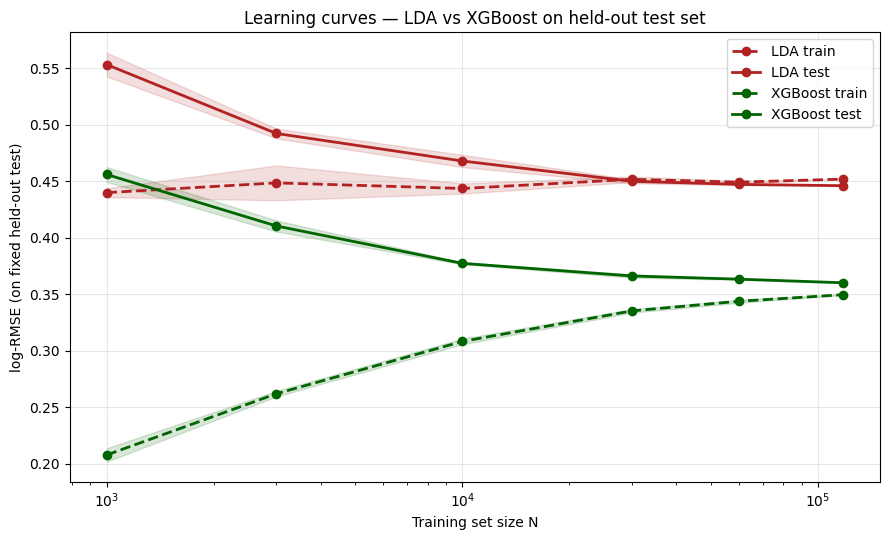


Generalization gap at full N:
  LDA:     test − train = -0.0058   plateaued
  XGBoost: test − train = +0.0105   plateaued


In [7]:
# ─────────────────────────────────────────────────────────────
# Learning curves: does XGBoost's edge grow, shrink, or stay flat
# as the training set grows? Has either model plateaued?
# ─────────────────────────────────────────────────────────────
full = build_complete_case(df)
train_pool, test_set = train_test_split(
    full, test_size=0.2, random_state=42, stratify=full['LUC'])
print(f"Train pool: {len(train_pool):,}   Held-out test: {len(test_set):,}")

sizes   = [1000, 3000, 10_000, 30_000, 60_000, len(train_pool)]
n_reps  = 3
results = []

for N in sizes:
    for rep in range(n_reps):
        sub = train_pool.sample(n=min(N, len(train_pool)),
                                random_state=100*rep + N) if N < len(train_pool) else train_pool

        pred_fn, _ = fit_lda_regression(
            sub[CONT_FEATURES].values, sub['LUC'].values, sub['log_V'].values)
        lda_tr = rmse(sub['log_V'].values,
                      pred_fn(sub[CONT_FEATURES].values, sub['LUC'].values))
        lda_te = rmse(test_set['log_V'].values,
                      pred_fn(test_set[CONT_FEATURES].values, test_set['LUC'].values))

        sub_xgb  = sub[CONT_FEATURES + ['LUC']].copy()
        test_xgb = test_set[CONT_FEATURES + ['LUC']].copy()
        sub_xgb['LUC']  = sub_xgb['LUC'].astype('category')
        test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
                                         categories=sub_xgb['LUC'].cat.categories)
        xgb_mod = fit_xgb(sub_xgb, sub['log_V'].values, seed=42+rep, n_est=400)
        xgb_tr  = rmse(sub['log_V'].values,          xgb_mod.predict(sub_xgb))
        xgb_te  = rmse(test_set['log_V'].values,      xgb_mod.predict(test_xgb))

        results.append({'N': N, 'rep': rep,
                        'LDA_train':  lda_tr, 'LDA_test':  lda_te,
                        'XGB_train':  xgb_tr, 'XGB_test':  xgb_te})
    print(f"  N={N:>6,}  done")

lc = pd.DataFrame(results).groupby('N').agg(['mean','std'])
print("\nLearning curve (mean across repeats):")
print(lc.xs('mean', axis=1, level=1).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
mean = lc.xs('mean', axis=1, level=1); sd = lc.xs('std', axis=1, level=1)
x = mean.index.values
for col, color, style, label in [
    ('LDA_train', 'firebrick', '--', 'LDA train'),
    ('LDA_test',  'firebrick', '-',  'LDA test'),
    ('XGB_train', 'darkgreen', '--', 'XGBoost train'),
    ('XGB_test',  'darkgreen', '-',  'XGBoost test')]:
    ax.plot(x, mean[col], style, color=color, lw=2, marker='o', label=label)
    ax.fill_between(x, mean[col]-sd[col], mean[col]+sd[col], color=color, alpha=0.15)

ax.set_xscale('log'); ax.set_xlabel('Training set size N')
ax.set_ylabel('log-RMSE (on fixed held-out test)')
ax.set_title('Learning curves — LDA vs XGBoost on held-out test set')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Narrative diagnostic
gap_lda = mean['LDA_test'].iloc[-1] - mean['LDA_train'].iloc[-1]
gap_xgb = mean['XGB_test'].iloc[-1] - mean['XGB_train'].iloc[-1]
plateau_lda = abs(mean['LDA_test'].iloc[-1] - mean['LDA_test'].iloc[-2]) < 0.005
plateau_xgb = abs(mean['XGB_test'].iloc[-1] - mean['XGB_test'].iloc[-2]) < 0.005

print(f"\nGeneralization gap at full N:")
print(f"  LDA:     test − train = {gap_lda:+.4f}   {'plateaued' if plateau_lda else 'still descending'}")
print(f"  XGBoost: test − train = {gap_xgb:+.4f}   {'plateaued' if plateau_xgb else 'still descending'}")

  replicate 5/30
  replicate 10/30


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/950227668.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/950227668.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  replicate 15/30


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/950227668.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/950227668.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  replicate 20/30


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/950227668.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  replicate 25/30


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_56439/950227668.py:33: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],


  replicate 30/30

Irreducible σ² estimate (from LUC=102 × HR stratum): 0.6375

Bias-variance decomposition across 30 bootstrap replicates:
              bias²  variance  σ²_est  bias²+var+σ²  empirical MSE
model                                                             
per_LUC_MLE  0.3732    0.0016  0.6375        1.0123         0.3748
LDA          0.1988    0.0005  0.6375        0.8369         0.1994
XGBoost      0.1287    0.0024  0.6375        0.7686         0.1311


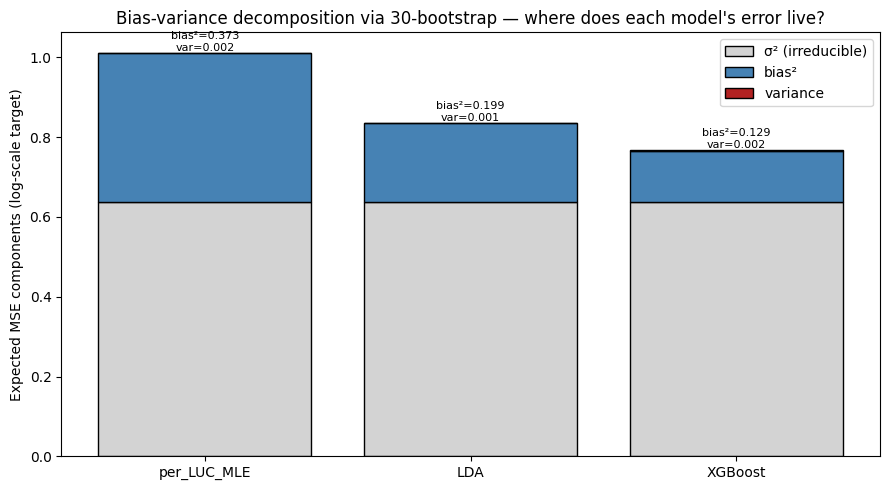

In [8]:
# ─────────────────────────────────────────────────────────────
# Bias-variance decomposition via bootstrap (PDF slide 33):
#   E_D[(ĥ(x;D) - y)²] ≈ σ² + bias² + variance
# Fit B bootstrap replicates of each model, compute per-test-point
# mean prediction (bias) and variance across replicates.
# σ² is estimated from the residual on a well-specified subset.
# ─────────────────────────────────────────────────────────────
full = build_complete_case(df)
train_pool, test_set = train_test_split(
    full, test_size=0.2, random_state=42, stratify=full['LUC'])

B = 30
y_true = test_set['log_V'].values
preds = {'per_LUC_MLE': np.zeros((B, len(test_set))),
         'LDA':         np.zeros((B, len(test_set))),
         'XGBoost':     np.zeros((B, len(test_set)))}

for b in range(B):
    sub = train_pool.sample(n=len(train_pool), replace=True, random_state=b)

    mu0 = sub['log_V'].mean()
    preds['per_LUC_MLE'][b] = test_set['LUC'].map(
        sub.groupby('LUC')['log_V'].mean()).fillna(mu0).values

    pred_fn, _ = fit_lda_regression(
        sub[CONT_FEATURES].values, sub['LUC'].values, sub['log_V'].values)
    preds['LDA'][b] = pred_fn(test_set[CONT_FEATURES].values,
                              test_set['LUC'].values)

    sub_xgb  = sub[CONT_FEATURES + ['LUC']].copy()
    test_xgb = test_set[CONT_FEATURES + ['LUC']].copy()
    sub_xgb['LUC']  = sub_xgb['LUC'].astype('category')
    test_xgb['LUC'] = pd.Categorical(test_xgb['LUC'],
                                     categories=sub_xgb['LUC'].cat.categories)
    preds['XGBoost'][b] = fit_xgb(sub_xgb, sub['log_V'].values,
                                  seed=b, n_est=400).predict(test_xgb)

    if (b + 1) % 5 == 0: print(f"  replicate {b+1}/{B}")

# Irreducible noise σ² — estimate from within-stratum residual on the
# stratum that passed goodness-of-fit best (LUC=102 × HR). This is your
# cleanest read on the true per-class noise floor.
good_stratum = (df['LUC'] == 102) & (df['BLDG_TYPE'] == 'HR - High Rise') & (df['TOTAL_VALUE'] > 0)
sigma2_est = np.log(df.loc[good_stratum, 'TOTAL_VALUE']).var()
print(f"\nIrreducible σ² estimate (from LUC=102 × HR stratum): {sigma2_est:.4f}")

rows = []
for name, P in preds.items():
    mean_pred = P.mean(axis=0)                                # E_D[ĥ(x)]
    bias2     = ((mean_pred - y_true) ** 2).mean()            # (E_D[ĥ] - y)²
    variance  = P.var(axis=0).mean()                          # E_D[(ĥ - E_D[ĥ])²]
    total_mse = ((P - y_true) ** 2).mean()
    rows.append({'model': name, 'bias²': bias2, 'variance': variance,
                 'σ²_est': sigma2_est,
                 'bias²+var+σ²': bias2 + variance + sigma2_est,
                 'empirical MSE': total_mse})

bv = pd.DataFrame(rows).set_index('model').round(4)
print(f"\nBias-variance decomposition across {B} bootstrap replicates:")
print(bv.to_string())

# Stacked bar
fig, ax = plt.subplots(figsize=(9, 5))
models = bv.index.tolist()
b = bv['bias²'].values; v = bv['variance'].values; s = np.full(len(models), sigma2_est)
ax.bar(models, s, label='σ² (irreducible)',      color='lightgray', edgecolor='k')
ax.bar(models, b, bottom=s, label='bias²',        color='steelblue', edgecolor='k')
ax.bar(models, v, bottom=s+b, label='variance',   color='firebrick', edgecolor='k')
ax.set_ylabel('Expected MSE components (log-scale target)')
ax.set_title(f'Bias-variance decomposition via {B}-bootstrap — where does each model\'s error live?')
ax.legend()
for i, (bi, vi) in enumerate(zip(b, v)):
    ax.text(i, sigma2_est + bi + vi + 0.005,
            f'bias²={bi:.3f}\nvar={vi:.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

0.001–0.002 out of ~0.8-1.0 total. You have enough data that every model is effectively deterministic across bootstrap resamples. This has one immediate implication: ensembling, regularization strength tuning, or any other variance-reduction technique will buy you essentially nothing. Don't waste time there